<a href="https://colab.research.google.com/github/aadithya-vimal/SamsungInnovationCampus/blob/main/practice_quantiles_boxplot_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practice Notebook: Quantiles and Box Plot

This notebook demonstrates **median, quartiles, deciles, percentiles, interquartile range (IQR), and box plots** using Python in Google Colab.

## Learning goals
By the end of this notebook, you should be able to:
- understand what quantiles are
- compute median, quartiles, deciles, and percentiles using NumPy
- interpret the five-number summary
- compute IQR and identify outliers
- draw and interpret box plots
- connect quantiles and box plots to real-world datasets

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# for reproducibility
np.random.seed(42)

## 1. What are quantiles?

Quantiles divide ordered data into equal-sized parts.

### Common quantiles
- **Median**: splits data into 2 equal parts. It is the **50th percentile**.
- **Quartiles**: split data into 4 parts.
  - $Q_1$ = 25th percentile
  - $Q_2$ = median = 50th percentile
  - $Q_3$ = 75th percentile
- **Deciles**: split data into 10 parts.
  - $D_1$ = 10th percentile
  - $D_5$ = 50th percentile
  - $D_9$ = 90th percentile
- **Percentiles**: split data into 100 parts.

Quantiles are useful because they tell us **where values lie within the data distribution**.

## 2. A simple example dataset

Let us start with a small dataset so that the calculations are easy to understand.

In [ ]:
data = np.array([12, 15, 17, 18, 19, 21, 22, 24, 26, 28, 30])

print("Data:", data)
print("Sorted data:", np.sort(data))
print("Number of observations:", len(data))

Data: [12 15 17 18 19 21 22 24 26 28 30]
Sorted data: [12 15 17 18 19 21 22 24 26 28 30]
Number of observations: 11


### Compute median, quartiles, and selected percentiles

In [ ]:
median = np.median(data)
q1 = np.percentile(data, 25)
q2 = np.percentile(data, 50)
q3 = np.percentile(data, 75)

d1 = np.percentile(data, 10)
d5 = np.percentile(data, 50)
d9 = np.percentile(data, 90)

p20 = np.percentile(data, 20)
p80 = np.percentile(data, 80)

print(f"Median = {median}")
print(f"Q1 = {q1}, Q2 = {q2}, Q3 = {q3}")
print(f"D1 = {d1}, D5 = {d5}, D9 = {d9}")
print(f"P20 = {p20}, P80 = {p80}")

Median = 21.0
Q1 = 17.5, Q2 = 21.0, Q3 = 25.0
D1 = 15.0, D5 = 21.0, D9 = 28.0
P20 = 17.0, P80 = 26.0


## 3. Five-number summary

The **five-number summary** is:
1. minimum
2. $Q_1$
3. median
4. $Q_3$
5. maximum

This summary is the basis for a **box plot**.

In [ ]:
minimum = np.min(data)
maximum = np.max(data)

print("Five-number summary")
print("Minimum :", minimum)
print("Q1      :", q1)
print("Median  :", median)
print("Q3      :", q3)
print("Maximum :", maximum)

Five-number summary
Minimum : 12
Q1      : 17.5
Median  : 21.0
Q3      : 25.0
Maximum : 30


## 4. Interquartile Range (IQR)

The **interquartile range** measures the spread of the middle 50% of the data.

$$
IQR = Q_3 - Q_1
$$

A common rule for detecting outliers is:

$$
\\text{Lower bound} = Q_1 - 1.5 \\times IQR
$$

$$
\\text{Upper bound} = Q_3 + 1.5 \\times IQR
$$

In [ ]:
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = data[(data < lower_bound) | (data > upper_bound)]

print(f"IQR = {iqr}")
print(f"Lower bound = {lower_bound}")
print(f"Upper bound = {upper_bound}")
print("Outliers:", outliers if len(outliers) > 0 else "None")

IQR = 7.5
Lower bound = 6.25
Upper bound = 36.25
Outliers: None


## 5. Visualizing quantiles on a number line

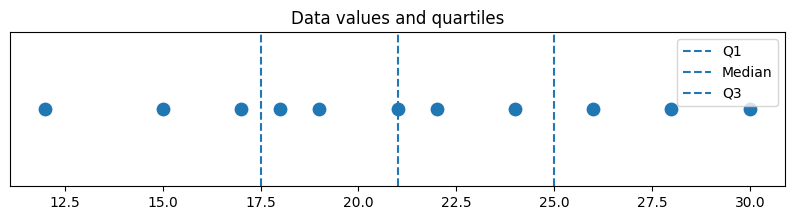

In [ ]:
plt.figure(figsize=(10, 2))
plt.scatter(data, np.zeros_like(data), s=80)
plt.axvline(q1, linestyle='--', label='Q1')
plt.axvline(median, linestyle='--', label='Median')
plt.axvline(q3, linestyle='--', label='Q3')
plt.yticks([])
plt.title("Data values and quartiles")
plt.legend()
plt.show()

## 6. Box plot

A **box plot** is a compact graphical summary of a dataset.

### Interpretation
- the **box** spans from $Q_1$ to $Q_3$
- the **line inside the box** is the median
- the **whiskers** extend to the typical non-outlier range
- points beyond the whiskers are plotted as **outliers**

Box plots are useful for:
- comparing different groups
- spotting skewness
- detecting outliers
- summarizing large datasets quickly

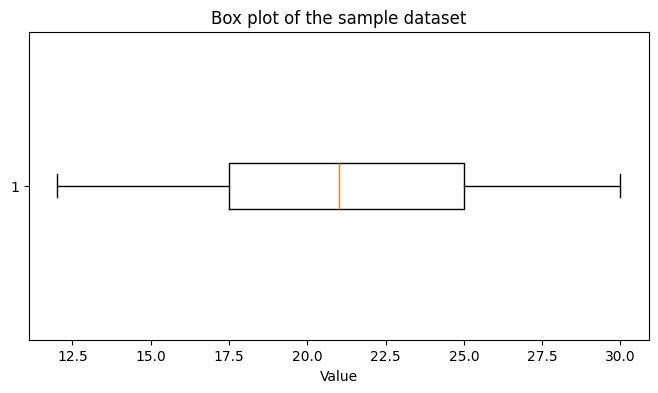

In [ ]:
plt.figure(figsize=(8, 4))
plt.boxplot(data, vert=False)
plt.title("Box plot of the sample dataset")
plt.xlabel("Value")
plt.show()

## 7. Real-world example 1: Student marks

Suppose the following values are marks scored by students in a class.

In [ ]:
marks = np.array([35, 42, 45, 49, 50, 54, 56, 58, 60, 62, 64, 67, 70, 72, 75, 78, 80, 82, 85, 95])

print("Median:", np.median(marks))
print("Q1:", np.percentile(marks, 25))
print("Q3:", np.percentile(marks, 75))
print("P90:", np.percentile(marks, 90))

Median: 63.0
Q1: 53.0
Q3: 75.75
P90: 82.30000000000001


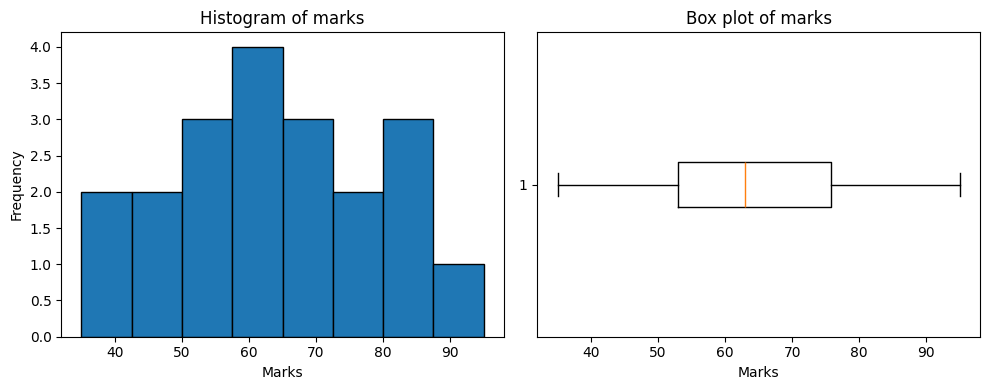

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(marks, bins=8, edgecolor='black')
plt.title("Histogram of marks")
plt.xlabel("Marks")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.boxplot(marks, vert=False)
plt.title("Box plot of marks")
plt.xlabel("Marks")

plt.tight_layout()
plt.show()

### Discussion
Use the above results to answer:
1. What is the median mark?
2. What mark separates the bottom 25% from the rest?
3. Are there any possible outliers?
4. Is the class distribution fairly symmetric or slightly skewed?

## 8. Real-world example 2: Daily app usage time

Let us simulate the number of minutes users spend on a mobile app in a day.

In [ ]:
usage = np.random.gamma(shape=2.2, scale=18, size=200)

print("Median usage:", np.median(usage))
print("Q1:", np.percentile(usage, 25))
print("Q3:", np.percentile(usage, 75))
print("P95:", np.percentile(usage, 95))

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(usage, bins=20, edgecolor='black')
plt.title("Histogram of daily app usage")
plt.xlabel("Minutes")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.boxplot(usage, vert=False)
plt.title("Box plot of daily app usage")
plt.xlabel("Minutes")

plt.tight_layout()
plt.show()

### Why is this useful in CS / AI?
Quantiles are useful when analyzing:
- user engagement data
- response times of servers
- latency measurements
- model inference times
- income, traffic, click counts, and other skewed data

For example, a company may prefer the **95th percentile latency** over the mean because it better reflects worst-case user experience.

## 9. Comparing multiple groups with box plots

Box plots are very useful when comparing multiple categories.

In [ ]:
section_A = np.random.normal(loc=68, scale=10, size=60)
section_B = np.random.normal(loc=74, scale=8, size=60)
section_C = np.random.normal(loc=70, scale=15, size=60)

plt.figure(figsize=(9, 5))
plt.boxplot([section_A, section_B, section_C], labels=["Section A", "Section B", "Section C"])
plt.title("Box plot comparison of three class sections")
plt.ylabel("Marks")
plt.show()

### Interpretation
From the box plot, compare:
- which section has the highest median
- which section has the greatest spread
- which section may contain outliers

## 10. Quantiles using SciPy

SciPy is often used in statistics workflows. While NumPy is commonly sufficient for percentiles, SciPy provides useful statistical utilities.

Here we compute the percentile rank of a specific value.

**Percentile rank** answers the question:
> What percentage of observations are less than or equal to this value?

In [ ]:
score = 75
percentile_rank = stats.percentileofscore(marks, score)

print(f"The score {score} is at approximately the {percentile_rank:.2f}th percentile.")

## 11. Outlier demonstration using box plot

Let us add extreme values and observe what happens.

In [ ]:
marks_with_outliers = np.append(marks, [5, 110])

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.boxplot(marks, vert=False)
plt.title("Original marks")

plt.subplot(1, 2, 2)
plt.boxplot(marks_with_outliers, vert=False)
plt.title("Marks with outliers")

plt.tight_layout()
plt.show()

### Observation
Notice how the box changes very little, but the outliers appear separately. This shows why box plots are robust and informative.

## 12. Practice Exercises

Try the following on your own.

### Exercise 1: Basic quantiles
Create a dataset of 15 values of your choice and compute:
- minimum
- maximum
- median
- Q1
- Q3
- IQR
- 10th percentile
- 90th percentile

### Exercise 2: Salary dataset
Assume the following monthly salaries:
`[22000, 25000, 26000, 27000, 30000, 32000, 34000, 36000, 40000, 45000, 90000]`

Tasks:
- compute the five-number summary
- compute IQR
- identify outliers
- draw a box plot
- explain why median may be better than mean for this dataset

### Exercise 3: Compare groups
Generate synthetic data for:
- model A accuracy scores
- model B accuracy scores
- model C accuracy scores

Create side-by-side box plots and compare the distributions.

### Exercise 4: Percentile rank
Choose one student's mark from the `marks` dataset and compute its percentile rank using SciPy.

### Exercise 5: Real-world interpretation
Suppose a website reports:
- median response time = 210 ms
- 95th percentile response time = 950 ms

What does this tell you about user experience?

In [ ]:
# Write your solutions here

## 13. Mini Challenge

Download or create a real dataset such as:
- exam marks
- app usage time
- daily rainfall
- website latency
- e-commerce order values

Then:
1. compute median, quartiles, deciles, and selected percentiles
2. draw a histogram
3. draw a box plot
4. identify outliers using the IQR rule
5. write 4 to 5 observations from the plots and statistics

## 14. Summary

In this notebook, you learned:
- how quantiles divide data into meaningful parts
- how median, quartiles, deciles, and percentiles are computed
- how IQR helps measure spread and detect outliers
- how box plots summarize data visually
- how these ideas apply to real-world CS and AI datasets